<div style="background-color:#003a72; padding:28px 24px; border-radius:10px;">
  <h1 style="color:white; margin-bottom:6px; font-size:26px;">From Scientific Question to SQL: AI-Assisted Viral Genomics</h1>
  <p style="color:#cce4ff; font-size:14px; margin:0;">A hands-on class for physics students | ViralPrimer Database | ELTE TTK</p>
</div>

## What this notebook is about

We will work with a real PostgreSQL database called **ViralPrimer**, which tracks nucleotide mutations in SARS-CoV-2 and other viruses across large global surveillance datasets (GISAID and CoVEO). Along the way, we will:

1. Understand the biological context at just enough depth to write meaningful queries
2. Practice translating scientific questions into SQL — step by step
3. See how **AI coding assistants in VSCode** can help — and where they fall short without context
4. Experience the difference that a **schema-aware AI assistant** (KooplexQuery) makes when the AI has access to the actual database structure

---
## Part 1 — The biological context

<div style="background-color:#f0f7ff; border-left:4px solid #003a72; padding:14px 18px; border-radius:4px; margin-bottom:12px;">
<strong>Why should a physicist care about viral mutations?</strong><br>
A mutating virus is a noisy information channel. Each new copy of the genome is produced with a certain error rate. Most errors are neutral or harmful to the virus — they disappear. Some confer an advantage (faster replication, immune evasion) and rise in frequency. Tracking which mutations rise, where, and when is epidemiological signal processing.
</div>

### 1.1 What is a nucleotide mutation?

Viral genomes are long sequences of nucleotides: the four bases **A** (adenine), **C** (cytosine), **G** (guanine), and **T** (thymine). The SARS-CoV-2 genome is about 30,000 nucleotides long.

A **nucleotide mutation** is written in a compact notation like `G28881A`. Read this as:  
> "At genome position 28881, the reference base is G, and in this sample it was observed as A."

So the format is: **[reference base][position][observed base]**.

### 1.2 What is a variant of concern (VOC)?

When a cluster of mutations spreads widely and shows changed behaviour (higher transmissibility, immune escape), health authorities classify it as a **Variant of Concern (VOC)** — for example Alpha, Delta, Omicron. In the database, a sample is tagged with its variant name (or `'Other'` if it doesn't match any known VOC).

### 1.3 What is a primer, and why does mutation tracking matter for diagnostics?

PCR-based diagnostic tests for COVID-19 work by amplifying a short piece of the viral genome using short synthetic DNA sequences called **primers**. A primer is typically 18–25 nucleotides long and must bind precisely to the viral genome.

**If a mutation falls within a primer's binding region, the test may fail to detect the virus** — a false negative. This is called *primer-binding site mismatch*. ViralPrimer was designed to monitor exactly this problem: which mutations are occurring in which primer target regions, and how frequently?

### 1.4 The databases: GISAID and CoVEO

ViralPrimer aggregates mutation data from two major sources:

| Database | Description |
|----------|-------------|
| **GISAID** | The largest global repository of SARS-CoV-2 sequences (millions of samples worldwide) |
| **CoVEO** | A European surveillance initiative with more curated, time-stamped sample data |

Most queries in this notebook use `database = 'GISAID'` or `database = 'CoVEO'` to select the source.

### 1.5 The reference genome

Mutations are always defined relative to a **reference genome** — the original "wild-type" sequence. For SARS-CoV-2, this is `NC_045512.2`, the Wuhan isolate sequenced in early 2020. All mutations in the database are expressed as differences from this reference.

For Mpox (formerly monkeypox), the reference is `NC_063383.1`.

---
## Part 2 — The database schema

Before writing any SQL, you need to understand the shape of the data. Below is the ViralPrimer schema. You don't need to memorise it — but you should be able to recognise which tables and columns are relevant for a given question.

![viralprimer_server.png](./attachment/viralprimer_server.png)

The key tables for today are:

| Table | What it stores |
|-------|----------------|
| `viralprimer_server_mutation` | One row per (mutation, date, country, database, variant). Contains raw sample counts. |
| `viralprimer_server_primer` | Primer names, sequences, and genomic coordinates (start/end position). |
| `viralprimer_server_browse_mutation` | Protein-level annotation for each nucleotide mutation: which gene, which codon, which amino acid change. |
| `viralprimer_server_gene` | Gene names and their genomic coordinates. |

**Key columns in `viralprimer_server_mutation`:**
- `nucleotide_mutation` — e.g. `'G28881A'`
- `position` — integer genome position (used for spatial JOINs with primer coordinates)
- `number_of_samples` — how many sequenced samples carried this mutation on this date
- `database` — `'GISAID'`, `'CoVEO'`, or `'mpx'`
- `reference_genome_id` — `'NC_045512.2'` for SARS-CoV-2
- `filter_001` / `filter_1` — boolean flags: is this mutation present in ≥0.01% / ≥1% of global samples?
- `variant` — VOC name or `'Other'`
- `country`, `date`

---
## Part 3 — Setup and database connection

In [59]:
# Standard imports
import os, psycopg2, time, warnings
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
warnings.filterwarnings('ignore', category=UserWarning)

# Load connection config from file (credentials are not stored in the notebook)
config = {}
with open('db_config.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        key, value = line.split('=', 1)
        config[key.strip()] = value.strip()

def run_query(sql):
    """Execute a SQL query and return a pandas DataFrame."""
    t0 = time.time()
    try:
        with psycopg2.connect(
            host=config['host'], port=config['port'],
            dbname=config['dbname'], user=config['user'],
            password=config['password'],
            options=config.get('options', '')
        ) as conn:
            df = pd.read_sql_query(sql, conn)
    except Exception as e:
        print(f'Query error: {e}')
        return None
    print(f'\033[94mRuntime: {time.time()-t0:.2f}s\033[0m')
    return df

# Quick connection test
test = run_query('SELECT COUNT(*) AS total_rows FROM viralprimer_server_mutation;')
print(test)

Runtime: 1.07s
   total_rows
0    53010397


---
## Part 4 — Translating scientific questions into SQL

This is the core of the class. For each question, we will:
1. Read and understand the biological question
2. Think about what it requires from the database (which tables, which filters)
3. Write and run the SQL
4. **Compare our result with what the AI assistant generated** — and discuss what it got right, what it missed, and why

For Questions 1–9, each SQL cell is followed by a screenshot. The first code shows our hand-written query result; the screenshot shows the output the AI assistant produced from the same natural-language question, with full ViralPrimer schema access via an K8plexQuery.


---

### What to look for in each comparison

Even with schema access, an AI assistant does not always produce a perfect query. The comparison is not just "AI right or wrong" — it is a window into *how* the AI reasons about a schema, and where domain knowledge is still needed to validate the output.

| Symbol | Meaning |
|--------|----------|
| ✅ | Correct or functionally equivalent |
| ⚠️ | Partially correct — right idea, wrong or incomplete execution |
| ❌ | Incorrect — wrong result, error, or empty output |

---

### For reference: what a schema-*un*aware assistant would produce

A general AI assistant without schema context might respond to Question 1 with something like:

```sql
-- Schema-unaware guess (plausible but wrong)
SELECT mutation_name, COUNT(*) AS frequency
FROM mutations
WHERE virus = 'SARS-CoV-2' AND source = 'CoVEO'
GROUP BY mutation_name
ORDER BY frequency DESC
LIMIT 10;
```

Wrong table name, wrong column names, and `COUNT(*)` instead of `SUM(number_of_samples)`. The comparisons that follow show how much schema access helps — and where the remaining gaps are.

---
### Section A — Mutations and Frequency

These questions explore how common different mutations are across the global sample collection.

<div style="background-color:#e8f5e9; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
<strong>Question 1:</strong> Which are the 10 most frequent SARS-CoV-2 nucleotide mutations in the CoVEO database, across all samples?
</div>

**Biological motivation:** Frequent mutations are usually not random — they either confer a selective advantage (spreading faster) or are closely linked to variants that do. Ranking mutations by total sample count is a quick way to identify the dominant evolutionary pressures in the dataset.

**Thinking through the SQL:**

The `mutation` table has one row per (mutation, date, country, variant) combination — so the same mutation appears in many rows. To get a total count across all rows, we need `SUM(number_of_samples)` and `GROUP BY nucleotide_mutation`.

We also need to filter to:
- SARS-CoV-2 reference genome: `reference_genome_id = 'NC_045512.2'`
- The CoVEO data source: `database = 'CoVEO'`

**Try it with a general AI assistant first.** If you typed the question above into Copilot without any schema, you might get something like:

```sql
-- ⚠️ What a schema-unaware AI might generate (plausible but wrong)
SELECT mutation_name, COUNT(*) AS frequency
FROM mutations
WHERE virus = 'SARS-CoV-2' AND source = 'CoVEO'
GROUP BY mutation_name
ORDER BY frequency DESC
LIMIT 10;
```

Notice: wrong table name (`mutations` vs `viralprimer_server_mutation`), wrong column names (`mutation_name`, `source`), and using `COUNT(*)` instead of `SUM(number_of_samples)` — because without the schema, the AI doesn't know there's a sample count column at all.

**The correct query:**

In [60]:
sql = '''
SELECT m.nucleotide_mutation,
       SUM(m.number_of_samples) AS total_samples
FROM viralprimer_server_mutation m
WHERE m.reference_genome_id = 'NC_045512.2'
  AND m.database = 'CoVEO'
GROUP BY m.nucleotide_mutation
ORDER BY total_samples DESC
LIMIT 10;
'''
df = run_query(sql)
df

Runtime: 2.78s


,nucleotide_mutation,total_samples
0,A23403G,3413421
1,C3037T,3276527
2,C14408T,3233727
3,C241T,2721145
4,C10029T,2532068
5,C22995A,2411997
6,G28881A,1727531
7,G28883C,1727242
8,G28882A,1726197
9,TA28270T,1701690


> 💬 **Reflect:** The top mutations here are likely to be recognisable hallmarks of Omicron or Delta — for example, mutations in the Spike protein that drove global waves. Does the notation follow the `[ref][pos][alt]` pattern we described?

<div style="background-color:#f5f5f5; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
    <strong>🤖 AI comparison — Question 1 &nbsp;&nbsp; ✅ Functionally correct</strong>
</div>

<img src="./attachment/question1.png"
     width="600"
     style="display:block; margin:20px auto; border:2px solid black; padding:5px;">

<p>
The AI produced identical numbers (A23403G tops both lists at 3,413,421 samples). However, instead of filtering by
<code>reference_genome_id = 'NC_045512.2'</code>, it used
<code>variant != 'Wild-type'</code> with a comment explaining its intent.
The result is accidentally correct: in the CoVEO database, virtually all non-wild-type records are SARS-CoV-2.
But the filter is fragile — on a different query it could silently exclude valid data.
</p>

<blockquote style="margin: 16px 0 0 0; padding-left: 14px; border-left: 4px solid #d0d0d0; color: #333;">
    The AI grasped the biological intent (exclude the reference sequence itself) but reached for a domain heuristic
    rather than the correct schema filter. This is a pattern worth watching: correct output does not always mean correct logic.
</blockquote>

<div style="background-color:#e8f5e9; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
<strong>Question 2:</strong> List 10 randomly selected SARS-CoV-2 mutations with a global frequency below 0.01% in the GISAID dataset.
</div>

**Biological motivation:** Most mutations in a large viral population are *rare* — they appear in only a handful of samples. These low-frequency variants are analogous to noise in a physical system. However, some of them may be early signals of emerging problems, such as mutations that allow the virus to escape a diagnostic test.

**Key concept — the `filter_001` column:**  
Rather than computing frequencies on the fly (which would require knowing the total sample count), the ViralPrimer database pre-computes boolean frequency flags:  
- `filter_001 = TRUE` means this mutation is present in ≥0.01% of all samples  
- `filter_001 = FALSE` means it is rarer than that  

Similarly, `filter_1` flags mutations present in ≥1% of all samples.

**Thinking through the SQL:** We want mutations where `filter_001 = FALSE`, from GISAID, for the SARS-CoV-2 reference genome. We use `ORDER BY RANDOM()` to get a non-deterministic sample.

In [62]:
sql = '''
SELECT nucleotide_mutation
FROM viralprimer_server_mutation
WHERE reference_genome_id = 'NC_045512.2'
  AND database = 'GISAID'
  AND filter_001 = FALSE
GROUP BY nucleotide_mutation
ORDER BY RANDOM()
LIMIT 10;
'''
df = run_query(sql)
df

Runtime: 8.86s


,nucleotide_mutation
0,AGAGG939A
1,A10130T
2,CAGAGGACGCGCAGG6354C
3,TC1165T
4,TAC9537T
5,GAAATCA25447G
6,TGGACCCTCAGATTCA28327T
7,T8707A
8,A16933C
9,T10528G


> 💬 **Reflect:** Run this cell twice — you should get different mutations each time because of `ORDER BY RANDOM()`. This kind of stochastic sampling is useful for quick exploratory checks on a large database.

---
<div style="background-color:#f5f5f5; border-left:4px solid #e65100; padding:14px 18px; border-radius:4px;">
<strong>🤖 AI comparison — Question 2 &nbsp;&nbsp; ⚠️ Filters right, but no deduplication</strong>
</div>

<img src="./attachment/question2.png"
     width="600"
     style="display: block; margin: 0 auto; border: 2px solid black; padding: 5px;">

The AI correctly identified `filter_001 = FALSE` and `database = 'GISAID'` — a non-obvious mapping that many AI assistants get wrong. However, it selected `number_of_samples` as a raw column alongside `nucleotide_mutation`, with no `GROUP BY`. The result is a flat scan returning individual rows, many of which are duplicate mutation names (since the same mutation appears on many dates). Our query deduplicates properly with `GROUP BY` before the random sampling.

> The AI understood the *filter* but not the *structure* of the question. "List 10 random mutations" requires one row per mutation — which in this table means aggregating first. Without understanding that each row represents one mutation on one date in one country, the AI had no reason to group. The schema alone does not tell you this; the data model documentation does.

<div style="background-color:#e8f5e9; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
<strong>Question 3:</strong> Which SARS-CoV-2 mutations appeared in Hungarian GISAID samples from 2021, and have a global frequency between 0.01% and 1%?
</div>

**Biological motivation:** If a mutation is rare globally but appears in a specific country at a specific time, it may indicate a locally circulating lineage. Conversely, finding globally intermediate-frequency mutations in Hungarian samples validates that local surveillance was capturing the broader epidemiological picture.

**Thinking through the SQL:** This query combines three kinds of filters:
1. **Geographic + temporal:** `country = 'Hungary'` and `EXTRACT(YEAR FROM date) = 2021`
2. **Frequency range:** `filter_001 = TRUE` (≥0.01%) AND `filter_1 = FALSE` (<1%)
3. **Source:** `database = 'GISAID'` and `reference_genome_id = 'NC_045512.2'`

We then `GROUP BY` the mutation to aggregate sample counts across all dates and sum them.

In [63]:
sql = '''
SELECT nucleotide_mutation,
       position,
       mutation,
       SUM(number_of_samples) AS total_samples
FROM viralprimer_server_mutation
WHERE reference_genome_id = 'NC_045512.2'
  AND database = 'GISAID'
  AND filter_001 = TRUE
  AND filter_1 = FALSE
  AND country = 'Hungary'
  AND EXTRACT(YEAR FROM date) = 2021
GROUP BY nucleotide_mutation, position, mutation
ORDER BY total_samples DESC;
'''
df = run_query(sql)
df.head(10)

Runtime: 2.29s


,nucleotide_mutation,position,mutation,total_samples
0,C4543T,4543,C->T,33
1,C18877T,18877,C->T,30
2,C26735T,26735,C->T,30
3,G5629T,5629,G->T,30
4,A16889G,16889,A->G,30
5,T26876C,26876,T->C,30
6,G28975C,28975,G->C,30
7,C11497T,11497,C->T,30
8,G15766T,15766,G->T,30
9,G13993T,13993,G->T,30


---
<div style="background-color:#f5f5f5; border-left:4px solid #e65100; padding:14px 18px; border-radius:4px;">
<strong>🤖 AI comparison — Question 3 &nbsp;&nbsp; ⚠️ Correct filters, missing aggregation</strong>
</div>

<img src="./attachment/question3.png"
     width="600"
     style="display: block; margin: 0 auto; border: 2px solid black; padding: 5px;">


The AI applied every filter correctly — `database`, `country`, frequency flags, and the year range (using `date BETWEEN '2021-01-01' AND '2021-12-31'` instead of `EXTRACT(YEAR FROM date) = 2021`, which is equally valid). But it again omitted `GROUP BY` and `SUM`. The result shows raw rows with `number_of_samples = 1` each, and the same mutation name appears repeatedly — for example, A10108G shows up three times as three separate date entries.

> This is the same aggregation failure as in Question 2, now in a more complex filtering context. It reinforces that the AI understands *which rows to select* but not *how to summarise them*. The `BETWEEN` vs `EXTRACT` choice is a good example of two valid SQL approaches to the same filter — worth discussing as a stylistic point.

<div style="background-color:#e8f5e9; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
<strong>Question 4:</strong> How many non-VOC samples contained the G28881A mutation on March 15, 2023, broken down by database?
</div>

**Biological motivation:** G28881A is a mutation in the N (nucleocapsid) gene. On a specific date, we want to know how many samples carrying this mutation were *not* classified as any known Variant of Concern — labelled `'Other'` in the database. If this mutation is appearing in non-VOC samples, it may be spreading independently of the major known lineages.

**Thinking through the SQL:** This is a relatively direct point-in-time lookup. The main subtleties are:
- Filtering to `variant = 'Other'` selects non-VOC samples
- Filtering to an exact date with `date = '2023-03-15'`
- Grouping by `database` to compare GISAID vs CoVEO counts side by side

In [64]:
sql = '''
SELECT database,
       SUM(number_of_samples) AS sample_count
FROM viralprimer_server_mutation
WHERE reference_genome_id = 'NC_045512.2'
  AND variant = 'Other'
  AND nucleotide_mutation = 'G28881A'
  AND date = '2023-03-15'
GROUP BY database;
'''
df = run_query(sql)
df

Runtime: 2.45s


,database,sample_count
0,CoVEO,673
1,GISAID,602


---
<div style="background-color:#f5f5f5; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
<strong>🤖 AI comparison — Question 4 &nbsp;&nbsp; ✅ Perfect</strong>
</div>

<img src="./attachment/question4.png"
     width="600"
     style="display: block; margin: 0 auto; border: 2px solid black; padding: 5px;">


The AI output is correct and actually more explicit than ours: it added the inline comment `-- non-VOC samples are stored as "Other"`, demonstrating that it understood the semantic meaning of the variant label from the schema documentation. The numbers match exactly (CoVEO: 673, GISAID: 602). It  omitted the `reference_genome_id` filter, but the combination of the specific mutation `G28881A` and `variant = 'Other'` already scopes the query unambiguously.

> This is the AI at its best: not just generating correct SQL, but demonstrating understanding through its own inline comments. The self-documenting query is a good habit to show students regardless of whether AI generated it.

<div style="background-color:#e8f5e9; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
<strong>Question 5:</strong> Which Mpox mutations increased most in sample count in the second half of 2022 compared to the first half?
</div>

**Biological motivation:** The 2022 Mpox (monkeypox) outbreak was unexpected and showed unusual spread patterns compared to previous outbreaks. Mutations that rose sharply after mid-2022 could reflect selective pressure, increased surveillance, or both.

**New concept — `CASE WHEN` for temporal splitting:** This query uses conditional aggregation. Instead of two separate queries (one per half-year), we compute both halves in a single pass by using `CASE WHEN` inside `SUM()`. This is a common pattern for before/after comparisons.

Note also that Mpox uses a different reference genome: `NC_063383.1`.

In [65]:
sql = '''
SELECT
    nucleotide_mutation,
    SUM(CASE WHEN date BETWEEN '2022-01-01' AND '2022-06-30'
             THEN number_of_samples ELSE 0 END) AS samples_h1,
    SUM(CASE WHEN date BETWEEN '2022-07-01' AND '2022-12-31'
             THEN number_of_samples ELSE 0 END) AS samples_h2
FROM viralprimer_server_mutation
WHERE reference_genome_id = 'NC_063383.1'
  AND database = 'mpx'
  AND date BETWEEN '2022-01-01' AND '2022-12-31'
GROUP BY nucleotide_mutation
HAVING
    SUM(CASE WHEN date BETWEEN '2022-07-01' AND '2022-12-31'
             THEN number_of_samples ELSE 0 END)
    >
    SUM(CASE WHEN date BETWEEN '2022-01-01' AND '2022-06-30'
             THEN number_of_samples ELSE 0 END)
ORDER BY (SUM(CASE WHEN date BETWEEN '2022-07-01' AND '2022-12-31'
             THEN number_of_samples ELSE 0 END) - SUM(CASE WHEN date BETWEEN '2022-01-01' AND '2022-06-30'
             THEN number_of_samples ELSE 0 END)) DESC
LIMIT 10;
'''
df = run_query(sql)
df

Runtime: 0.05s


,nucleotide_mutation,samples_h1,samples_h2
0,G181980A,186,642
1,G186578A,167,608
2,G3111A,292,716
3,C194099T,293,715
4,C3818T,298,718
5,G3522A,295,712
6,G193392A,301,717
7,C193688T,298,713
8,C183519T,294,709
9,G2591A,298,699


> 💬 **Reflect:** The `HAVING` clause here filters *after* aggregation — it's the GROUP BY equivalent of `WHERE`. We can't use `WHERE` to filter on aggregated values. This is an important SQL pattern for any data-heavy scientific workflow.

---
<div style="background-color:#f5f5f5; border-left:4px solid #1565c0; padding:14px 18px; border-radius:4px;">
<strong>🤖 AI comparison — Question 5 &nbsp;&nbsp; ✅ AI approach is stronger</strong>
</div>

<img src="./attachment/question5.png"
     width="600"
     style="display: block; margin: 0 auto; border: 2px solid black; padding: 5px;">


Look carefully at the results. Our query returns ten mutations where `samples_h1 = 0` — these are mutations that simply did not exist in the first half of 2022 at all, so any appearance in H2 ranks as the largest "increase". That is technically correct but obscures what the question was really asking: which *established* mutations grew.

The AI used a CTE (Common Table Expression) approach: two separate subqueries for each half-year, then a `LEFT JOIN` with `COALESCE` to handle mutations that appear in only one period. The result shows genuine growth — G181980A went from 186 to 642 samples (increase: 456). This is a more informative and robust answer.

> When the AI produces a stronger result, resist the urge to simply adopt it — first understand *why* it is better. Here the key insight is the `LEFT JOIN` + `COALESCE` pattern, which gracefully handles missing data across the two periods. CTEs also make the logic much easier to read and audit. Both are worth teaching independently of the AI comparison.

---
### Section B — From Nucleotide to Protein

So far we've worked at the DNA level. The next two questions connect nucleotide changes to protein-level effects — which requires a JOIN between tables.

<div style="background-color:#e8f5e9; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
<strong>Question 6:</strong> What protein-level change does the nucleotide mutation C23604A cause by itself?
</div>

**Biological motivation:** Proteins are encoded by triplets of nucleotides called codons. A change in one nucleotide can change the encoded amino acid (*non-synonymous mutation*), or it might encode the same amino acid (*synonymous / silent mutation*). Understanding which amino acid changes result from a given nucleotide mutation is essential to assess functional impact.

**The schema for this query:** `viralprimer_server_browse_mutation` stores the codon-level annotation. Each mutation row has three fields — `mutation_codon_1`, `mutation_codon_2`, `mutation_codon_3` — representing the three possible positions within a codon. If the mutation acts alone (without another co-occurring mutation in the same codon), the other two positions are labelled `'synonymous'`.

We JOIN with `viralprimer_server_gene` to retrieve the human-readable gene name.

**This is a case where a general AI assistant is very likely to fail** — the column name `nucletotide_mutation` (note the typo: one `e` missing) exists in the actual schema. No AI without schema access would guess that typo correctly.

In [54]:
sql = '''
SELECT g.gene_name,
       m.mutation_residue
FROM viralprimer_server_browse_mutation m
INNER JOIN viralprimer_server_gene g ON m.gene_name_id = g.id
WHERE m.nucletotide_mutation = 'C23604A'
  AND m.reference_genome_id = 'NC_045512.2'
  AND (
      (m.mutation_codon_1 = 'C23604A' AND m.mutation_codon_2 = 'synonymous' AND m.mutation_codon_3 = 'synonymous')
   OR (m.mutation_codon_2 = 'C23604A' AND m.mutation_codon_1 = 'synonymous' AND m.mutation_codon_3 = 'synonymous')
   OR (m.mutation_codon_3 = 'C23604A' AND m.mutation_codon_1 = 'synonymous' AND m.mutation_codon_2 = 'synonymous')
  );
'''
df = run_query(sql)
df

Runtime: 0.21s


,gene_name,mutation_residue
0,S,P681H


> 💬 **Reflect:** C23604A is the mutation encoding the **P681H** change in the Spike protein — a hallmark of the Alpha and Delta variants that affects the furin cleavage site, enhancing cell entry. The query isolates this effect by requiring that *only* this one nucleotide change is present in the codon (the others must be `'synonymous'`).

---
<div style="background-color:#f5f5f5; border-left:4px solid #b71c1c; padding:14px 18px; border-radius:4px;">
<strong>🤖 AI comparison — Question 6 &nbsp;&nbsp; ❌ Wrong join target, empty result</strong>
</div>

<img src="./attachment/question6.png"
     width="600"
     style="display: block; margin: 0 auto; border: 2px solid black; padding: 5px;">


The AI identified the right starting table (`viralprimer_server_browse_mutation`) and the correct mutation filter (`nucletotide_mutation = 'C23604A'`), but then joined to `viralprimer_server_refseq` — a table that either does not exist or does not contain a column matching `r.name = 'NC_045512.2'`. The result is an empty dataset. Our query joined to `viralprimer_server_gene` on `gene_name_id`, which is the correct relationship, and returned the expected result: gene S, mutation residue P681H.

There is a second error: the AI omitted the codon-position logic entirely. Without the `mutation_codon_1/2/3 = 'synonymous'` conditions, the query would return all protein changes involving this nucleotide — including cases where a second mutation in the same codon is also contributing to the amino acid change.

> This is the most dangerous kind of failure — the query runs without an error message but returns nothing, which could easily be mistaken for "no such mutation exists." The AI found the right table but made up a join path to a non-existent table. Even with full schema access, an AI can confuse which tables are related to which.

<div style="background-color:#e8f5e9; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
<strong>Question 7:</strong> Which SARS-CoV-2 variants and nucleotide mutations result in an A→D amino acid substitution at position 570 of the Spike protein, and appear in more than 1% of global samples?
</div>

**Biological motivation:** The A570D mutation in the Spike protein was a defining feature of the Alpha (B.1.1.7) variant. This query shows how to work backwards from a protein-level event (a specific amino acid change at a specific position) to the nucleotide-level mutations that cause it — and to connect those back to variant labels and epidemiological counts.

**Three-table JOIN:** This query joins `browse_mutation` → `gene` → `mutation`, linking protein annotation to sample frequency data.

In [55]:
sql = '''
SELECT DISTINCT
    m.variant,
    bm.nucletotide_mutation AS nucleotide_mutation,
    bm.mutation_residue    AS protein_mutation,
    SUM(m.number_of_samples) AS total_samples
FROM viralprimer_server_browse_mutation bm
JOIN viralprimer_server_gene g
    ON bm.gene_name_id = g.id
JOIN viralprimer_server_mutation m
    ON bm.nucletotide_mutation = m.nucleotide_mutation
   AND bm.reference_genome_id = m.reference_genome_id
WHERE g.gene_name = 'S'
  AND bm.residue_positions = 570
  AND bm.mutation_residue = 'A570D'
  AND m.filter_1 = TRUE
  AND m.reference_genome_id = 'NC_045512.2'
GROUP BY m.variant, bm.nucletotide_mutation, bm.mutation_residue
ORDER BY total_samples DESC;
'''
df = run_query(sql)
df.head(10)

Runtime: 2.19s


,variant,nucleotide_mutation,protein_mutation,total_samples
0,Alpha,C23271A,A570D,2761738
1,Other,C23271A,A570D,47158
2,Omicron,C23271A,A570D,512
3,Delta,C23271A,A570D,392
4,Gamma,C23271A,A570D,124
5,Beta,C23271A,A570D,20


---
<div style="background-color:#f5f5f5; border-left:4px solid #b71c1c; padding:14px 18px; border-radius:4px;">
<strong>🤖 AI comparison — Question 7 &nbsp;&nbsp; ❌ Column does not exist</strong>
</div>

<img src="./attachment/question7.png"
     width="600"
     style="display: block; margin: 0 auto; border: 2px solid black; padding: 5px;">

The AI generated a query that selects `m.variant` from `viralprimer_server_browse_mutation` — but `variant` is a column in `viralprimer_server_mutation`, not in `browse_mutation`. The two tables have similar names and overlapping concepts, which confused the AI into attributing a column from one to the other. It also used `gene_name = 'Spike'` instead of the abbreviated form `'S'` that the schema actually stores.

The query fails with an explicit SQL error, which is at least unambiguous — unlike Question 6, where the failure was silent.

> This is a classic cross-table hallucination: the AI knew that variant information exists somewhere in the schema, but incorrectly inferred it was available in the table it was currently querying. Checking which columns belong to which table — not just whether they exist in the database — is a critical validation step when reviewing any AI-generated JOIN query.

---
### Section C — Primers and Diagnostic Vulnerability

The most applied section: connecting mutation data to diagnostic assay design.

<div style="background-color:#e8f5e9; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
<strong>Question 8:</strong> How many distinct mutations overlap with the Corman-N forward primer target region in CoVEO?
</div>

**Biological motivation:** The "Corman-N" primer (developed by the Charité Berlin group, one of the first widely used COVID-19 PCR tests) targets the N gene. Any mutation falling within the primer's binding region could reduce test sensitivity. This query counts how many unique mutations have been observed in that region.

**The spatial JOIN:** Primers are defined by a genomic start and end coordinate. Mutations are defined by a single position. The JOIN condition `m.position BETWEEN p.start AND p.end` connects them geometrically — like a range query. This is the structural bridge between the two tables.

**This is another query a general AI assistant would likely get wrong** — it would not know that the spatial relationship between mutations and primers is encoded as a `BETWEEN` condition on coordinates, nor would it know to filter by `p.type = 'F'` (forward primer) or `p.target_gene = 'N'`.

In [56]:
sql = '''
SELECT COUNT(DISTINCT m.nucleotide_mutation) AS distinct_mutations_in_primer_region
FROM viralprimer_server_mutation m
JOIN viralprimer_server_primer p
  ON m.position BETWEEN p.start AND p.end
WHERE m.reference_genome_id = 'NC_045512.2'
  AND p.primer_name LIKE '%Corman%'
  AND p.target_gene = 'N'
  AND p.type = 'F'
  AND m.database = 'CoVEO';
'''
df = run_query(sql)
df

Runtime: 5.85s


,distinct_mutations_in_primer_region
0,53


---
<div style="background-color:#f5f5f5; border-left:4px solid #b71c1c; padding:14px 18px; border-radius:4px;">
<strong>🤖 AI comparison — Question 8 &nbsp;&nbsp; ❌ Wrong column name, returns 0</strong>
</div>

<img src="./attachment/question8.png"
     width="600"
     style="display: block; margin: 0 auto; border: 2px solid black; padding: 5px;">

The AI used `primer_set = 'Corman-N'` — but no such column exists. The correct filter is `primer_name LIKE '%Corman%'` combined with `target_gene = 'N'`. The AI also prefixed the table name with a schema namespace — `viralprimer.viralprimer_server_primer` — which does not match the actual table path, and added a spurious `variant != 'Wild-type'` filter that would further restrict results even if the other issues were fixed. The query runs without an error but returns 0.

> Three separate errors in one query, each individually sufficient to produce a wrong answer. Notice that none of them causes a syntax error — they all fail silently. This illustrates why result validation is essential: a query that runs and returns a number is not necessarily a query that answers your question. The correct answer here is 53; zero is a plausible-looking but completely wrong result.

<div style="background-color:#e8f5e9; border-left:4px solid #2e7d32; padding:14px 18px; border-radius:4px;">
<strong>Question 9:</strong> Which Sarbeco primer regions (Charité design) have the highest cumulative number of samples with overlapping mutations in GISAID?
</div>

**Biological motivation:** Not all primer binding sites are equally vulnerable. This query ranks the Sarbeco primer regions by cumulative sample burden — i.e., how many total samples globally have any mutation in that region. High-burden primers are candidates for redesign.

In [57]:
sql = '''
SELECT p.primer_name || '-' || p.type AS primer,
       SUM(m.number_of_samples)       AS total_samples_with_mutation
FROM viralprimer_server_mutation m
JOIN viralprimer_server_primer p
  ON m.position BETWEEN p.start AND p.end
WHERE m.reference_genome_id = 'NC_045512.2'
  AND p.original_primer_name LIKE '%Sarbeco%'
  AND p.origin LIKE '%Charité%'
  AND p.type = 'F'
  AND m.database = 'GISAID'
GROUP BY primer
ORDER BY total_samples_with_mutation DESC
LIMIT 10;
'''
df = run_query(sql)
df

Runtime: 0.29s


,primer,total_samples_with_mutation
0,Corman-E-F,9046703
1,Corman-N-F,300049


---
<div style="background-color:#f5f5f5; border-left:4px solid #b71c1c; padding:14px 18px; border-radius:4px;">
<strong>🤖 AI comparison — Question 9 &nbsp;&nbsp; ❌ Wrong column, operator precedence error, empty result</strong>
</div>

<img src="./attachment/question9.png"
     width="600"
     style="display: block; margin: 0 auto; border: 2px solid black; padding: 5px;">

The AI made the same `primer_set` error as in Question 8 — the column does not exist. The correct filters are `original_primer_name LIKE '%Sarbeco%'` and `origin LIKE '%Charité%'`. There is also a subtle operator precedence bug: the WHERE clause reads `primer_set ILIKE '%Sarbeco%' OR primer_set ILIKE '%Charité%' AND database = 'GISAID'`. In SQL, `AND` binds tighter than `OR`, so this is evaluated as `primer_set ILIKE '%Sarbeco%' OR (primer_set ILIKE '%Charité%' AND database = 'GISAID')` — not what was intended. The schema-prefixed table names and the `variant != 'Wild-type'` filter compound the problem. The query returns empty.

> Operator precedence is a classic SQL trap that catches experienced developers too. The fix is simple — wrap OR conditions in parentheses — but the bug is easy to miss visually. It is worth showing the corrected version: `(p.original_primer_name LIKE '%Sarbeco%' AND p.origin LIKE '%Charité%')`.

---
## Part 5 — Reflections on AI-assisted SQL

Nine side-by-side comparisons give us enough data to see real patterns.

### The scorecard

| Question | Topic | Verdict | Core failure (if any) |
|---|---|---|---|
| Q1 | Most frequent mutations | ✅ | Used domain heuristic instead of schema filter — got lucky |
| Q2 | Rare mutations | ⚠️ | Correct filter, no deduplication or aggregation |
| Q3 | Hungarian mutations, 2021 | ⚠️ | Correct filters, missing GROUP BY + SUM |
| Q4 | G28881A on a date | ✅ | Perfect, with self-documenting comment |
| Q5 | Mpox H1 vs H2 | ✅ | CTE approach is *better* than our query |
| Q6 | Nucleotide → protein | ❌ | Wrong join table, empty result, missing codon logic |
| Q7 | A570D in Spike | ❌ | Column from wrong table, SQL error |
| Q8 | Mutations in Corman-N | ❌ | Wrong column name, returns 0 silently |
| Q9 | Sarbeco primer burden | ❌ | Wrong column + operator precedence bug, empty result |

### What the AI got right — and why

Questions 1, 4, and 5 succeeded. Q4 is the clearest case: the AI used schema documentation to understand that `variant = 'Other'` means non-VOC, and its self-annotating comment demonstrates genuine semantic comprehension, not just pattern matching. Q5 is the most instructive: the AI produced a *better* query than ours by using a CTE with `LEFT JOIN` and `COALESCE`, which correctly handles mutations that only appear in one half-year.

### The recurring failure: aggregation

Questions 2 and 3 share the same root cause: the AI correctly identified which rows to select but did not aggregate them. This is not a schema knowledge problem — `SUM` and `GROUP BY` are standard SQL. It is a *data model* problem: to know that aggregation is needed, you must know that a single mutation appears in many rows (one per date, country, variant). That interpretation is not written in the column names; it is written in the documentation about what the table represents.

### The silent failure problem

Questions 6, 8, and 9 all return empty results with no error. This is harder to catch than an explicit SQL error (like Q7) because an empty result looks plausible — maybe there really are no mutations in that primer region, or no protein-level annotation for that mutation. Without knowing the correct answer, you would have no reason to distrust the output.

This is why the discipline of result validation matters more than query generation. The question is not only "does this query run?" but "is this result plausible given what I know?"

### Summary

| | General AI (no schema) | AI assistant |
|---|---|---|
| Table and column names | ❌ Guesses | ✅ Usually correct |
| Aggregation logic | ❌ Often missing | ⚠️ Sometimes missing |
| Semantic value meaning | ❌ Cannot know | ⚠️ If documented |
| Data model (rows = ?) | ❌ Cannot know | ❌ Rarely inferred |
| Cross-table column scope | ❌ Guesses | ⚠️ Can confuse tables |
| Operator precedence | ❌ Can fail | ❌ Can still fail |

Schema access eliminates the most basic errors. But three out of nine queries still returned wrong or empty results despite full schema access. **The AI shifts the work from writing SQL to reviewing it — which is faster, but not zero effort.**

---
## Part 6 — Optional bonus: visualising mutation trends

SQL gets you the data. Python does the visualisation. Here is a quick example using one of the query results.

Feel free to modify the query or the plot to explore something you found interesting in the earlier sections.

Runtime: 2.56s


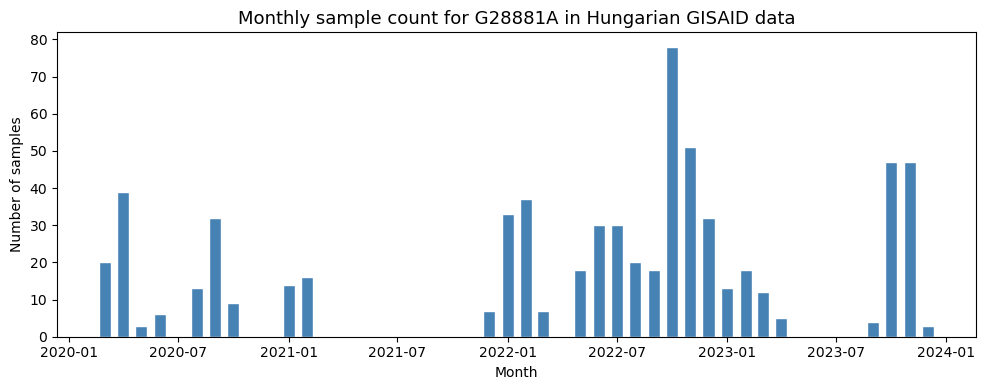

In [58]:
# Example: monthly sample count for G28881A in Hungary (GISAID)
sql = '''
SELECT DATE_TRUNC('month', date) AS month,
       SUM(number_of_samples)    AS samples
FROM viralprimer_server_mutation
WHERE reference_genome_id = 'NC_045512.2'
  AND database = 'GISAID'
  AND nucleotide_mutation = 'G28881A'
  AND country = 'Hungary'
GROUP BY month
ORDER BY month;
'''
df = run_query(sql)

if df is not None and len(df) > 0:
    df['month'] = pd.to_datetime(df['month'])
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(df['month'], df['samples'], width=20, color='steelblue', edgecolor='white')
    ax.set_title('Monthly sample count for G28881A in Hungarian GISAID data', fontsize=13)
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of samples')
    plt.tight_layout()
    plt.show()
else:
    print('No data returned — check your database connection.')

---
## Summary

In this class we covered:

**Biology:**
- Nucleotide mutations and the `[ref][pos][alt]` notation
- Variants of Concern vs non-VOC samples
- How PCR primers work, and why mutation-primer overlap matters for diagnostics
- The connection between nucleotide changes and protein-level amino acid substitutions

**SQL patterns:**
- `SUM` + `GROUP BY` for aggregating across many rows per mutation
- Boolean frequency filters (`filter_001`, `filter_1`) as pre-computed frequency bins
- `EXTRACT(YEAR FROM date)` for temporal filtering
- `CASE WHEN` inside `SUM()` for before/after comparisons (conditional aggregation)
- Spatial range JOIN: `m.position BETWEEN p.start AND p.end`
- Multi-table JOINs to connect genomic, protein, and epidemiological layers

**AI tooling:**
- A general AI assistant in VSCode generates plausible-looking but structurally incorrect SQL without schema context
- An AI assistant given access to the actual schema, generates SQL that runs correctly — because it knows the real table names, column names, and relationships
- The workflow of translating a scientific question into SQL is itself something an AI can help scaffold, if it has the right context

---
*Notebook developed for ELTE TTK physics students | ViralPrimer project | 2026*